In [1]:
%cd ~/Source/flow-matching-mnist

/home/luke-padmore/Source/flow-matching-mnist


In [3]:
import torchvision
import torch
import matplotlib.pyplot as plt 
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn 
from models.unet import UNet
import mlflow
import numpy as np
import os, sys
from models.ode_solvers import euler_solver, rk2_solver, make_vf,create_samples
from pathlib import Path 

mlflow.set_experiment('flow-matching-debugging')
os.environ["MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING"] = "true"
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

batch_size = 64
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Pad(2,padding_mode='constant'),
    transforms.Normalize((0.5,), (0.5,))]
)
trainset = torchvision.datasets.MNIST(root = '/home/luke-padmore/Source/flow-matching-mnist/data',
                                      train=True,
                                      download=True,
                                      transform=transform)
trainloader = DataLoader(trainset,
                        batch_size=batch_size,
                        shuffle=True,
                        num_workers=4)

/home/luke-padmore/miniconda3/envs/ml/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

NUM_BUCKETS = 20
EPS = 1e-6


@dataclass
class BucketStats:
    mse_sums: torch.Tensor
    cossim_sums: torch.Tensor
    log_norm_ratio_sums: torch.Tensor
    freqs: torch.Tensor

    @classmethod
    def zeros(cls, num_buckets: int, device: torch.device):
        z = torch.zeros(num_buckets, device=device, dtype=torch.float32)
        return cls(z.clone(), z.clone(), z.clone(), z.clone())

    def update(
        self,
        mse_batch: torch.Tensor,
        cossim_batch: torch.Tensor,
        log_norm_ratio_batch: torch.Tensor,
        bins: torch.Tensor,
    ):
        self.mse_sums += torch.bincount(bins, weights=mse_batch, minlength=self.freqs.numel())
        self.cossim_sums += torch.bincount(bins, weights=cossim_batch, minlength=self.freqs.numel())
        self.log_norm_ratio_sums += torch.bincount(
            bins, weights=log_norm_ratio_batch, minlength=self.freqs.numel()
        )
        self.freqs += torch.bincount(bins, minlength=self.freqs.numel()).to(self.freqs.dtype)

    def means(self):
        safe = self.freqs.clamp_min(1.0)
        mse = torch.where(self.freqs > 0, self.mse_sums / safe, torch.zeros_like(self.mse_sums))
        cossim = torch.where(self.freqs > 0, self.cossim_sums / safe, torch.zeros_like(self.cossim_sums))
        log_ratio = torch.where(
            self.freqs > 0, self.log_norm_ratio_sums / safe, torch.zeros_like(self.log_norm_ratio_sums)
        )
        return mse, cossim, log_ratio

    def add_(self, other: "BucketStats"):
        self.mse_sums += other.mse_sums
        self.cossim_sums += other.cossim_sums
        self.log_norm_ratio_sums += other.log_norm_ratio_sums
        self.freqs += other.freqs


def flow_matching_step_uncond(model, x1, loss_fn, device, fixed_x0=None):
    x1 = x1.to(device)
    b = x1.size(0)

    if fixed_x0 is None:
        x0 = torch.randn_like(x1)
    else:
        x0 = fixed_x0[:b].to(device)
        if x0.shape != x1.shape:
            raise ValueError(f"fixed_x0 shape {x0.shape} must match x1 shape {x1.shape}")

    t = torch.rand(b, 1, 1, 1, device=device)
    xt = (1 - t) * x0 + t * x1

    v_est = model(xt, t)
    v_true = x1 - x0
    mse_batch = loss_fn(v_est, v_true).mean(dim=(1, 2, 3))  # per-sample
    return mse_batch, t, v_est, v_true


def log_bucket_histograms(stats: BucketStats, epoch: int, step: int, key_suffix: str = ""):
    mse_m, cos_m, log_m = stats.means()
    bucket_idx = torch.arange(stats.freqs.numel())

    plots = {
        "mse": mse_m,
        "cosine_similarity": cos_m,
        "log_norm_ratio": log_m,
        "bin_frequency": stats.freqs,
    }

    for name, values in plots.items():
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(bucket_idx.cpu().numpy(), values.detach().cpu().numpy())
        ax.set_title(f"epoch {epoch:03d} {name}")
        ax.set_xlabel("t bucket")
        ax.set_ylabel(name)
        ax.set_xticks(bucket_idx.cpu().numpy())
        fig.tight_layout()

        fig.canvas.draw()
        w, h = fig.canvas.get_width_height()
        img = np.asarray(fig.canvas.buffer_rgba()).reshape(h, w, 4)
        mlflow.log_image(img, key=f"{name}{key_suffix}", step=step)
        plt.close(fig)


def train_uncond_with_buckets(
    model,
    train_loader,
    num_epochs: int,
    optim,
    device,
    log_every_steps: int = 100,
    num_buckets: int = NUM_BUCKETS,
    fixed_x0: torch.Tensor | None = None,  # pass fixed noise here for single-batch overfit debugging
):
    loss_fn = nn.MSELoss(reduction="none")
    boundaries = torch.linspace(0, 1, num_buckets - 1, device=device)

    global_step = 0
    best_train = float("inf")
    overall = BucketStats.zeros(num_buckets, device)

    for epoch in range(num_epochs):
        model.train()
        running = 0.0
        epoch_stats = BucketStats.zeros(num_buckets, device)

        for x1, _ in train_loader:
            optim.zero_grad(set_to_none=True)

            mse_batch, t, v_est, v_true = flow_matching_step_uncond(
                model=model,
                x1=x1,
                loss_fn=loss_fn,
                device=device,
                fixed_x0=fixed_x0,
            )
            loss = mse_batch.mean()
            loss.backward()
            optim.step()

            mse_step = float(loss.item())
            running += mse_step

            cossim_batch = F.cosine_similarity(v_est.flatten(1), v_true.flatten(1), dim=1)
            v_est_norm = torch.linalg.vector_norm(v_est.flatten(1), dim=1)
            v_true_norm = torch.linalg.vector_norm(v_true.flatten(1), dim=1)
            log_ratio_batch = torch.log(v_est_norm + EPS) - torch.log(v_true_norm + EPS)

            bins = torch.bucketize(t[:, 0, 0, 0], boundaries, right=True)
            epoch_stats.update(mse_batch, cossim_batch, log_ratio_batch, bins)

            if global_step % log_every_steps == 0:
                mse_m, cos_m, log_m = epoch_stats.means()
                print(
                    f"[epoch {epoch:03d} | step {global_step:06d}] "
                    f"mse={mse_step:.6f} mse_mean={mse_m.mean().item():.6f} "
                    f"cossim_mean={cos_m.mean().item():.6f} log_ratio_mean={log_m.mean().item():.6f}"
                )
                log_bucket_histograms(epoch_stats, epoch=epoch, step=global_step)

            global_step += 1

        train_mse_epoch = running / len(train_loader)
        best_train = min(best_train, train_mse_epoch)
        overall.add_(epoch_stats)

        print(f"[epoch {epoch:03d}] train_mse_epoch={train_mse_epoch:.6f}")
        mlflow.log_metric("train_mse_epoch", float(train_mse_epoch), step=epoch)

        mse_m, cos_m, log_m = epoch_stats.means()
        for i, v in enumerate(mse_m.detach().cpu().tolist()):
            mlflow.log_metric(f"mse_bucket_{i:02d}", float(v), step=epoch)
        for i, v in enumerate(cos_m.detach().cpu().tolist()):
            mlflow.log_metric(f"cossim_bucket_{i:02d}", float(v), step=epoch)
        for i, v in enumerate(log_m.detach().cpu().tolist()):
            mlflow.log_metric(f"log_norm_ratio_bucket_{i:02d}", float(v), step=epoch)

        log_bucket_histograms(epoch_stats, epoch=epoch, step=epoch, key_suffix="_epoch_summary")

    log_bucket_histograms(overall, epoch=num_epochs, step=num_epochs, key_suffix="_overall")
    return best_train


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

images, labels = next(iter(trainloader))
single_batch_loader = DataLoader(
    TensorDataset(images, labels),
    batch_size=len(images),
    shuffle=False,
)

model = UNet([1, 32, 64, 128], 8, 8, 8, 128).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=1e-3)



In [4]:
# Drop-in single-batch overfit (class-conditional)

import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from models.config import UNetConfig
from models.unet import UNet, ClassCondUNet
from utils.train import train_loop_class_cond
from models.ode_solvers import sample_conditional, euler_solver

# Reproducibility
seed = 42
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
images, labels = next(iter(trainloader))  
single_batch_loader = DataLoader(
    TensorDataset(images, labels),
    batch_size=len(images),
    shuffle=False,
)

# 2) model
n_classes = int(labels.max().item()) + 1     # MNIST -> 10
null_id = n_classes + 1                      # your convention

cfg = UNetConfig(
    in_channels=1,
    base_channels=32,
    mult=2.0,
    n_layers=3,
    d_trunk=8,
    d_concat=8,
    group_norm_size=8,
    d_time=128,
)
core = UNet.from_config(cfg).to(device)
model = ClassCondUNet(core=core, n_classes=null_id + 1, d_cls_emb=128).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=1e-3)

# 3) overfit train (disable cond dropout first)
best = train_loop_class_cond(
    model=model,
    train_loader=single_batch_loader,
    val_loader=None,
    num_epochs=200,
    optim=optim,
    device=device,
    null_id=null_id,
    p_drop=0.0,  # important for pure overfit sanity check
)

print("best mse:", best)

# 4) conditional sampling sanity check
# one sample per class row
y_vis = torch.arange(0, n_classes, device=device).repeat(8)  # 8 rows
samples = sample_conditional(
    model=model,
    y=y_vis,
    image_shape=tuple(images.shape[1:]),  # (C,H,W)
    ode_solver=euler_solver,
    n_steps=50,
    guidance_scale=1.0,   # plain conditional first
    null_id=null_id,      # needed if guidance_scale != 1, safe to pass always
    device=device,
    seed=0,
)

# `samples` shape: (len(y_vis), C, H, W)
print(samples.shape)


[epoch 000 | step 000000] train_mse_step=1.881075
[epoch 000] train_mse_epoch=1.881075
[epoch 001] train_mse_epoch=1.391506
[epoch 002] train_mse_epoch=1.213073
[epoch 003] train_mse_epoch=1.115598
[epoch 004] train_mse_epoch=1.037571
[epoch 005] train_mse_epoch=0.926648
[epoch 006] train_mse_epoch=0.828984
[epoch 007] train_mse_epoch=0.773992
[epoch 008] train_mse_epoch=0.699149
[epoch 009] train_mse_epoch=0.672343
[epoch 010] train_mse_epoch=0.611491
[epoch 011] train_mse_epoch=0.586147
[epoch 012] train_mse_epoch=0.571616
[epoch 013] train_mse_epoch=0.499893
[epoch 014] train_mse_epoch=0.548939
[epoch 015] train_mse_epoch=0.495741
[epoch 016] train_mse_epoch=0.537578
[epoch 017] train_mse_epoch=0.462518
[epoch 018] train_mse_epoch=0.509152
[epoch 019] train_mse_epoch=0.446752
[epoch 020] train_mse_epoch=0.444338
[epoch 021] train_mse_epoch=0.497126
[epoch 022] train_mse_epoch=0.405261
[epoch 023] train_mse_epoch=0.447259
[epoch 024] train_mse_epoch=0.446330
[epoch 025] train_mse_epo

(np.float64(-0.5), np.float64(341.5), np.float64(273.5), np.float64(-0.5))

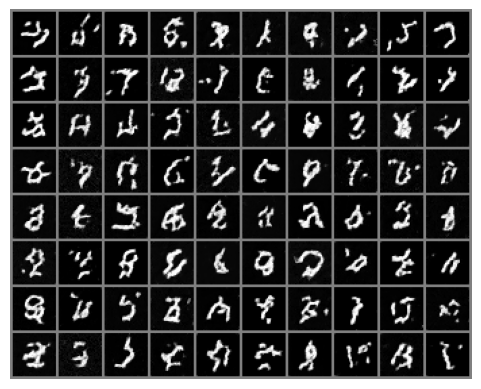

In [20]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

grid = make_grid(samples, nrow=10)  # 10 cols => 8 rows for 80 images

plt.imshow(grid[0].cpu().numpy(), cmap="gray")
plt.axis('off')


